# First-Order SISO Models for USV Motion Control

Fits first-order linear models to USV dynamics using least-squares system identification.

## Surge model: throttle → speed

**Model (continuous time)**
$$\tau \dot{v} + v = K \, u$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $v$ | surge speed | m/s |
| $u$ | throttle command | — (normalized −1…1) |
| $K$ | steady-state gain | m/s per unit throttle |
| $\tau$ | time constant | s |

**Transfer function**
$$G(s) = \frac{V(s)}{U(s)} = \frac{K}{\tau s + 1}$$

**Identification approach:** fit in discrete time as an ARX(1,1) structure
$$v[k+1] = a\,v[k] + b\,u[k]$$
using ordinary least squares, then convert to physical parameters:
$$\tau = -\frac{\Delta t}{\ln a}, \qquad K = \frac{b}{1-a}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg
import scipy.signal

DATA_CSV = 'usv_step_response_150_280s.csv'
DT = 0.1   # sample period (s)

## 1. Load data

In [2]:
df = pd.read_csv(DATA_CSV)
t  = df['time_s'].to_numpy()
u  = df['throttle_norm'].to_numpy()   # input
v  = df['speed_mps'].to_numpy()       # output

print(f'Samples : {len(t)}')
print(f'Duration: {t[-1]:.1f} s at {1/DT:.0f} Hz')
print(f'Throttle: [{u.min():.3f}, {u.max():.3f}]')
print(f'Speed   : [{v.min():.3f}, {v.max():.3f}] m/s')

Samples : 1300
Duration: 130.0 s at 10 Hz
Throttle: [0.000, 0.390]
Speed   : [0.017, 2.925] m/s


## 2. Visualize input / output

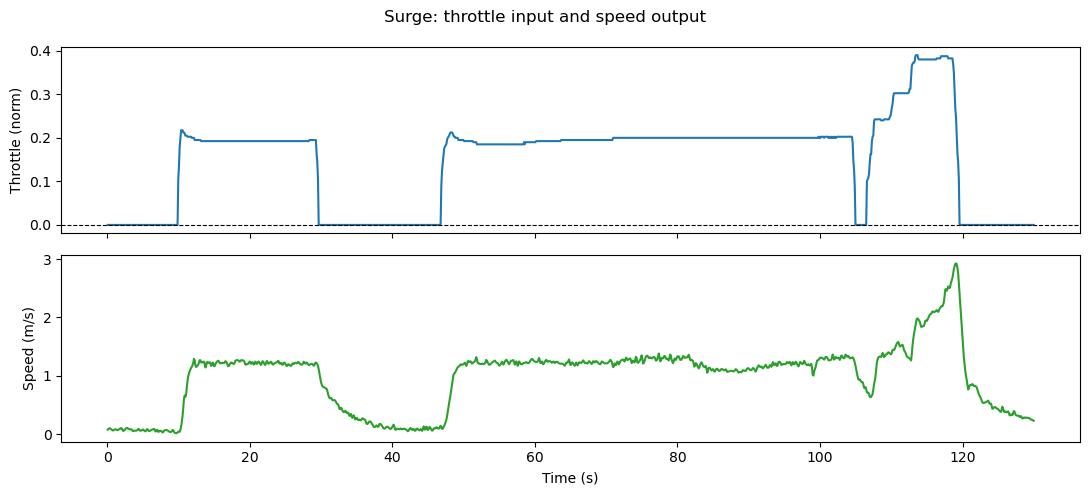

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax1.plot(t, u, color='C0')
ax1.set_ylabel('Throttle (norm)')
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax2.plot(t, v, color='C2')
ax2.set_ylabel('Speed (m/s)')
ax2.set_xlabel('Time (s)')
fig.suptitle('Surge: throttle input and speed output', fontsize=12)
plt.tight_layout()
plt.savefig('surge_io.png', dpi=150)
plt.show()

## 3. Least-squares identification

Stack one-step-ahead regression vectors and solve:
$$\begin{bmatrix} a \\ b \end{bmatrix}
= \left(\Phi^\top\Phi\right)^{-1}\Phi^\top y, \qquad
\Phi = \begin{bmatrix} v[0] & u[0] \\ \vdots & \vdots \\ v[N-2] & u[N-2] \end{bmatrix},\quad
y = \begin{bmatrix} v[1] \\ \vdots \\ v[N-1] \end{bmatrix}$$

In [4]:
Phi = np.column_stack([v[:-1], u[:-1]])   # (N-1) x 2
y   = v[1:]                               # (N-1,)

params, residuals, rank, sv = scipy.linalg.lstsq(Phi, y)
a, b = params

print(f'Discrete-time parameters:')
print(f'  a = {a:.6f}')
print(f'  b = {b:.6f}')
print(f'\nStability: |a| = {abs(a):.4f}  ({"stable" if abs(a) < 1 else "UNSTABLE"})')

Discrete-time parameters:
  a = 0.950098
  b = 0.320488

Stability: |a| = 0.9501  (stable)


## 4. Physical parameters

In [5]:
tau = -DT / np.log(a)
K   = b / (1.0 - a)

print(f'Time constant       τ = {tau:.3f} s')
print(f'Steady-state gain   K = {K:.3f} m/s per unit throttle')
print(f'  (max speed at full throttle: {K*1.0:.2f} m/s)')
print(f'\nTransfer function:  G(s) = {K:.3f} / ({tau:.3f}s + 1)')

Time constant       τ = 1.954 s
Steady-state gain   K = 6.422 m/s per unit throttle
  (max speed at full throttle: 6.42 m/s)

Transfer function:  G(s) = 6.422 / (1.954s + 1)


## 5. Simulate and validate

Drive the fitted discrete model with the measured throttle sequence and compare
the simulated speed against the actual GPS speed.

In [6]:
v_sim = np.empty_like(v)
v_sim[0] = v[0]
for k in range(len(v) - 1):
    v_sim[k+1] = a * v_sim[k] + b * u[k]

rmse = np.sqrt(np.mean((v - v_sim)**2))
r2   = 1 - np.sum((v - v_sim)**2) / np.sum((v - v.mean())**2)

print(f'Simulation RMSE = {rmse:.4f} m/s')
print(f'Simulation R²   = {r2:.4f}')

Simulation RMSE = 0.1455 m/s
Simulation R²   = 0.9295


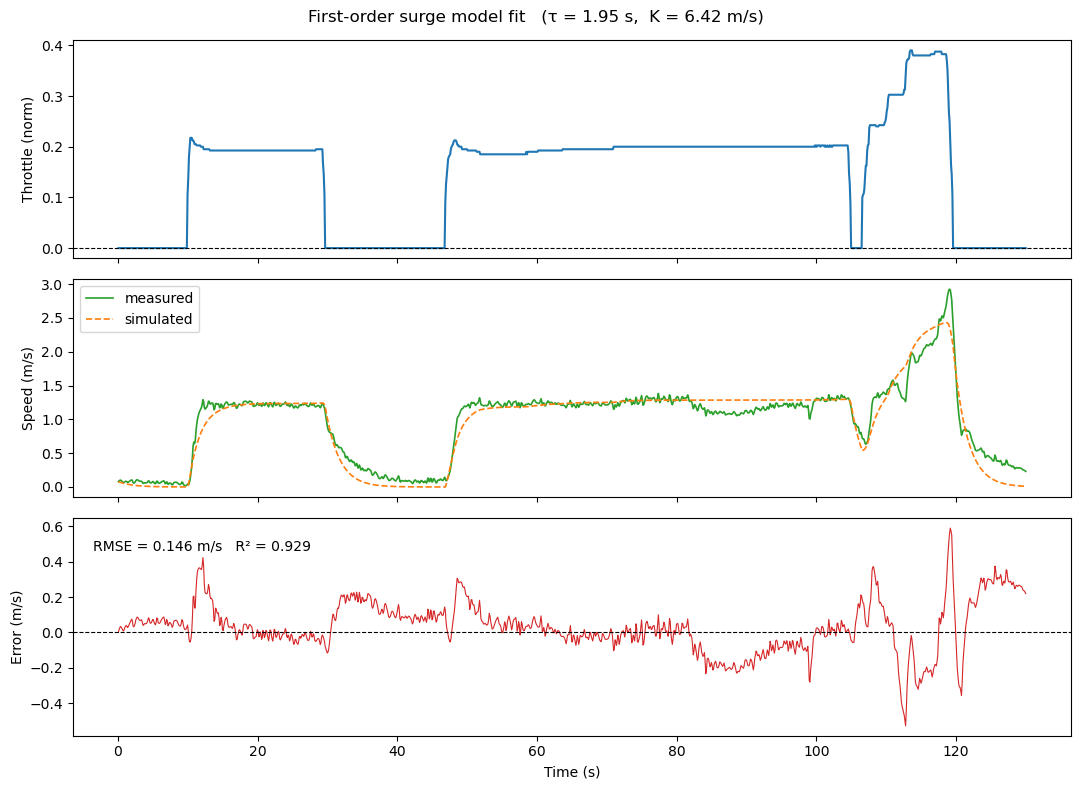

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle(f'First-order surge model fit   (τ = {tau:.2f} s,  K = {K:.2f} m/s)',
             fontsize=12)

axes[0].plot(t, u, color='C0')
axes[0].set_ylabel('Throttle (norm)')
axes[0].axhline(0, color='k', lw=0.8, ls='--')

axes[1].plot(t, v,     color='C2', label='measured',  lw=1.2)
axes[1].plot(t, v_sim, color='C1', label='simulated', lw=1.2, ls='--')
axes[1].set_ylabel('Speed (m/s)')
axes[1].legend()

axes[2].plot(t, v - v_sim, color='C3', lw=0.8)
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_ylabel('Error (m/s)')
axes[2].set_xlabel('Time (s)')
axes[2].text(0.02, 0.90, f'RMSE = {rmse:.3f} m/s   R² = {r2:.3f}',
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.savefig('surge_model_fit.png', dpi=150)
plt.show()

## 6. Model step response

Theoretical step response to a unit throttle command, showing the time constant
and steady-state speed predicted by the identified model.

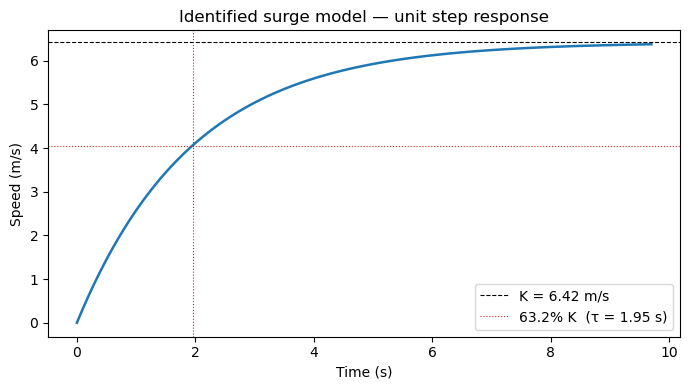

Summary
-------
G(s) = 6.422 / (1.954 s + 1)
τ    = 1.95 s
K    = 6.42 m/s
RMSE = 0.1455 m/s
R²   = 0.9295


In [8]:
t_step = np.arange(0, 5 * tau, DT)
sys    = scipy.signal.TransferFunction([K], [tau, 1])
_, y_step = scipy.signal.step(sys, T=t_step)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_step, y_step, color='C0', lw=1.8)
ax.axhline(K,         color='k',  lw=0.8, ls='--', label=f'K = {K:.2f} m/s')
ax.axhline(0.632 * K, color='C3', lw=0.8, ls=':',  label=f'63.2% K  (τ = {tau:.2f} s)')
ax.axvline(tau,       color='C3', lw=0.8, ls=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Speed (m/s)')
ax.set_title('Identified surge model — unit step response')
ax.legend()
plt.tight_layout()
plt.savefig('surge_step_response.png', dpi=150)
plt.show()

print(f'Summary')
print(f'-------')
print(f'G(s) = {K:.3f} / ({tau:.3f} s + 1)')
print(f'τ    = {tau:.2f} s')
print(f'K    = {K:.2f} m/s')
print(f'RMSE = {rmse:.4f} m/s')
print(f'R²   = {r2:.4f}')

---
## Yaw-rate model: rudder → yaw rate

**Model (continuous time)**
$$\tau_r \dot{r} + r = K_r \, \delta$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $r$ | yaw rate | rad/s |
| $\delta$ | rudder command | — (normalized −1…1) |
| $K_r$ | steady-state gain | rad/s per unit rudder |
| $\tau_r$ | time constant | s |

Same ARX(1,1) identification approach as surge.

In [9]:
delta = df['rudder_norm'].to_numpy()    # input
r     = df['yaw_rate_rps'].to_numpy()   # output

print(f'Rudder  : [{delta.min():.3f}, {delta.max():.3f}]')
print(f'Yaw rate: [{r.min():.3f}, {r.max():.3f}] rad/s')

Rudder  : [-1.000, 0.695]
Yaw rate: [-0.679, 0.519] rad/s


## 7. Visualize rudder / yaw-rate

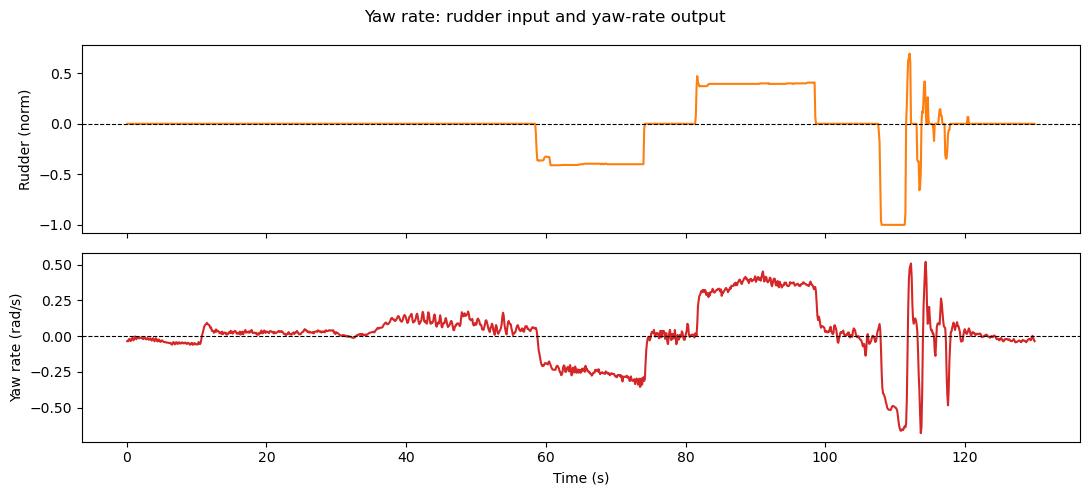

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax1.plot(t, delta, color='C1')
ax1.set_ylabel('Rudder (norm)')
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax2.plot(t, r, color='C3')
ax2.set_ylabel('Yaw rate (rad/s)')
ax2.set_xlabel('Time (s)')
ax2.axhline(0, color='k', lw=0.8, ls='--')
fig.suptitle('Yaw rate: rudder input and yaw-rate output', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Least-squares identification

In [11]:
Phi_r = np.column_stack([r[:-1], delta[:-1]])
y_r   = r[1:]

params_r, _, _, _ = scipy.linalg.lstsq(Phi_r, y_r)
a_r, b_r = params_r

print(f'Discrete-time parameters:')
print(f'  a_r = {a_r:.6f}')
print(f'  b_r = {b_r:.6f}')
print(f'\nStability: |a_r| = {abs(a_r):.4f}  ({"stable" if abs(a_r) < 1 else "UNSTABLE"})')

Discrete-time parameters:
  a_r = 0.808828
  b_r = 0.147361

Stability: |a_r| = 0.8088  (stable)


## 9. Physical parameters

In [12]:
tau_r = -DT / np.log(a_r)
K_r   = b_r / (1.0 - a_r)

print(f'Time constant       τ_r = {tau_r:.3f} s')
print(f'Steady-state gain   K_r = {K_r:.3f} rad/s per unit rudder')
print(f'\nTransfer function:  G_r(s) = {K_r:.3f} / ({tau_r:.3f}s + 1)')

Time constant       τ_r = 0.471 s
Steady-state gain   K_r = 0.771 rad/s per unit rudder

Transfer function:  G_r(s) = 0.771 / (0.471s + 1)


## 10. Simulate and validate

In [13]:
r_sim = np.empty_like(r)
r_sim[0] = r[0]
for k in range(len(r) - 1):
    r_sim[k+1] = a_r * r_sim[k] + b_r * delta[k]

rmse_r = np.sqrt(np.mean((r - r_sim)**2))
r2_r   = 1 - np.sum((r - r_sim)**2) / np.sum((r - r.mean())**2)

print(f'Simulation RMSE = {rmse_r:.4f} rad/s')
print(f'Simulation R²   = {r2_r:.4f}')

Simulation RMSE = 0.0813 rad/s
Simulation R²   = 0.8261


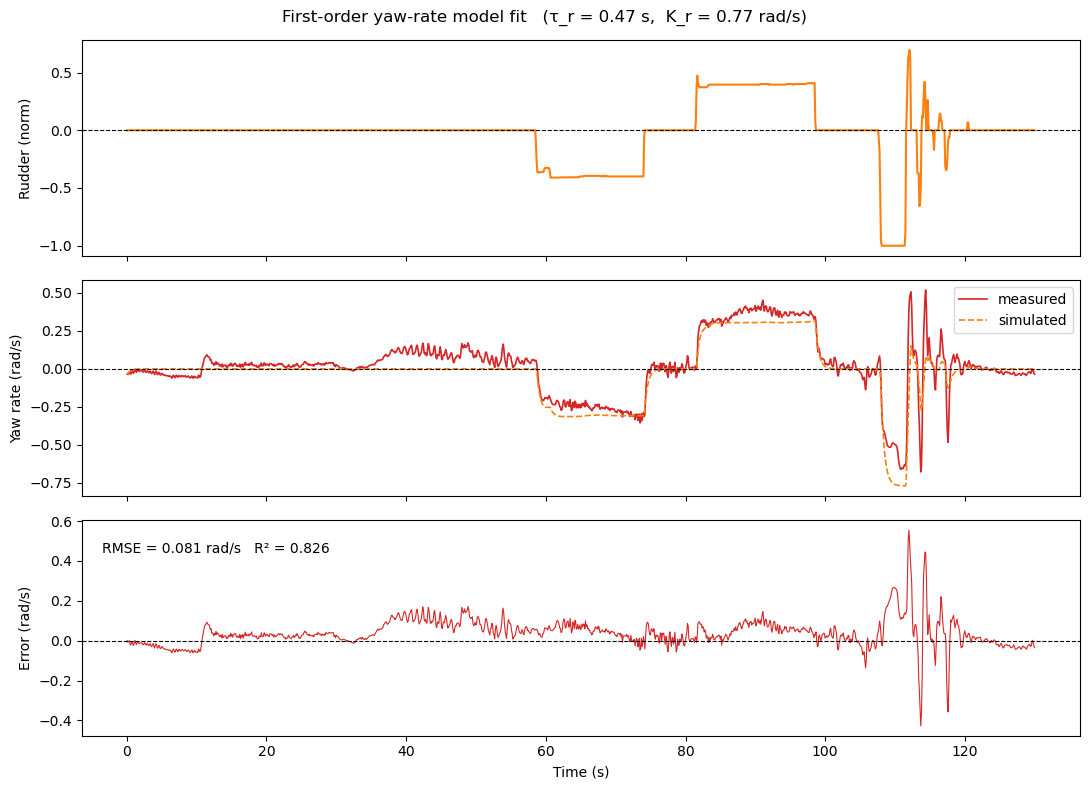

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle(f'First-order yaw-rate model fit   (τ_r = {tau_r:.2f} s,  K_r = {K_r:.2f} rad/s)',
             fontsize=12)

axes[0].plot(t, delta, color='C1')
axes[0].set_ylabel('Rudder (norm)')
axes[0].axhline(0, color='k', lw=0.8, ls='--')

axes[1].plot(t, r,     color='C3', label='measured',  lw=1.2)
axes[1].plot(t, r_sim, color='C1', label='simulated', lw=1.2, ls='--')
axes[1].set_ylabel('Yaw rate (rad/s)')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].legend()

axes[2].plot(t, r - r_sim, color='C3', lw=0.8)
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_ylabel('Error (rad/s)')
axes[2].set_xlabel('Time (s)')
axes[2].text(0.02, 0.90, f'RMSE = {rmse_r:.3f} rad/s   R² = {r2_r:.3f}',
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

## 11. Model step response

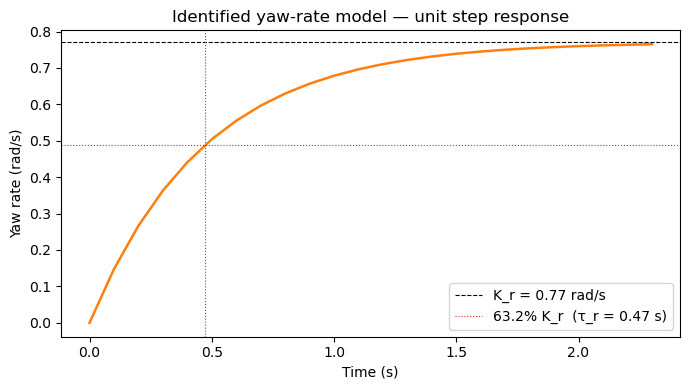

Summary
-------
G_r(s) = 0.771 / (0.471 s + 1)
τ_r    = 0.47 s
K_r    = 0.77 rad/s
RMSE   = 0.0813 rad/s
R²     = 0.8261


In [15]:
t_step_r = np.arange(0, 5 * tau_r, DT)
sys_r    = scipy.signal.TransferFunction([K_r], [tau_r, 1])
_, y_step_r = scipy.signal.step(sys_r, T=t_step_r)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_step_r, y_step_r, color='C1', lw=1.8)
ax.axhline(K_r,         color='k',  lw=0.8, ls='--', label=f'K_r = {K_r:.2f} rad/s')
ax.axhline(0.632 * K_r, color='C3', lw=0.8, ls=':',  label=f'63.2% K_r  (τ_r = {tau_r:.2f} s)')
ax.axvline(tau_r,       color='C3', lw=0.8, ls=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Yaw rate (rad/s)')
ax.set_title('Identified yaw-rate model — unit step response')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Summary')
print(f'-------')
print(f'G_r(s) = {K_r:.3f} / ({tau_r:.3f} s + 1)')
print(f'τ_r    = {tau_r:.2f} s')
print(f'K_r    = {K_r:.2f} rad/s')
print(f'RMSE   = {rmse_r:.4f} rad/s')
print(f'R²     = {r2_r:.4f}')

---
## Diagnostics for nonlinear model structure

Three targeted checks to decide which terms belong in a nonlinear state-space model:
1. Speed-dependent rudder effectiveness — does K_r scale with surge speed?
2. Drag nonlinearity in surge — linear vs. quadratic drag during coasting
3. Rudder-induced surge drag — does large rudder deflection slow the vessel?

### Diagnostic 1: speed-dependent rudder effectiveness

Compare two yaw-rate regressors:
- **Model A** (current): `r[k+1] = a·r[k] + b·δ[k]`  — constant gain
- **Model B**: `r[k+1] = a·r[k] + b·(δ[k]·v[k])` — gain scales with speed

If Model B fits better, K_r is speed-dependent and the nonlinear model should include a `δ·v` coupling term.

Model A  (constant K_r):       R² = 0.8261  RMSE = 0.0813 rad/s
Model B  (K_r · v coupling):   R² = 0.7945  RMSE = 0.0884 rad/s
Improvement ΔR²: -0.0315


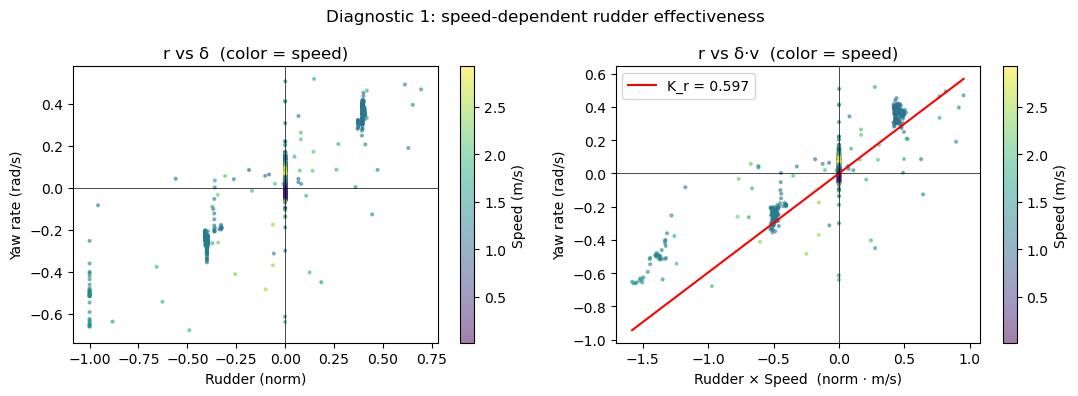

In [16]:
# Model A — already fit above (a_r, b_r)
r2_A = r2_r

# Model B — replace delta with delta*v as the input regressor
Phi_B   = np.column_stack([r[:-1], delta[:-1] * v[:-1]])
params_B, _, _, _ = scipy.linalg.lstsq(Phi_B, r[1:])
a_B, b_B = params_B

r_sim_B    = np.empty_like(r)
r_sim_B[0] = r[0]
for k in range(len(r) - 1):
    r_sim_B[k+1] = a_B * r_sim_B[k] + b_B * delta[k] * v[k]

r2_B   = 1 - np.sum((r - r_sim_B)**2) / np.sum((r - r.mean())**2)
rmse_B = np.sqrt(np.mean((r - r_sim_B)**2))

print(f'Model A  (constant K_r):       R² = {r2_A:.4f}  RMSE = {rmse_r:.4f} rad/s')
print(f'Model B  (K_r · v coupling):   R² = {r2_B:.4f}  RMSE = {rmse_B:.4f} rad/s')
print(f'Improvement ΔR²: {r2_B - r2_A:+.4f}')

# Scatter: measured yaw rate vs delta and delta*v
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

sc1 = ax1.scatter(delta, r, c=v, cmap='viridis', s=4, alpha=0.5)
plt.colorbar(sc1, ax=ax1, label='Speed (m/s)')
ax1.set_xlabel('Rudder (norm)')
ax1.set_ylabel('Yaw rate (rad/s)')
ax1.set_title('r vs δ  (color = speed)')
ax1.axhline(0, color='k', lw=0.5); ax1.axvline(0, color='k', lw=0.5)

sc2 = ax2.scatter(delta * v, r, c=v, cmap='viridis', s=4, alpha=0.5)
plt.colorbar(sc2, ax=ax2, label='Speed (m/s)')
# Overlay best-fit line for the coupling term
xfit = np.linspace((delta*v).min(), (delta*v).max(), 100)
ax2.plot(xfit, (b_B / (1 - a_B)) * xfit, 'r-', lw=1.5, label=f'K_r = {b_B/(1-a_B):.3f}')
ax2.set_xlabel('Rudder × Speed  (norm · m/s)')
ax2.set_ylabel('Yaw rate (rad/s)')
ax2.set_title('r vs δ·v  (color = speed)')
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)
ax2.legend()

plt.suptitle('Diagnostic 1: speed-dependent rudder effectiveness', fontsize=12)
plt.tight_layout()
plt.show()

### Diagnostic 2: drag nonlinearity in surge

During zero-throttle coasting, thrust = 0 so:
$$m\dot{v} = -D_1 v - D_2 v^2$$

Numerically differentiate the measured speed during coasting segments,
then fit both a linear (`-D₁v`) and quadratic (`-D₁v - D₂v²`) drag model.
A better quadratic fit indicates the nonlinear term belongs in the state-space model.

Coasting samples: 352  (35.2 s)
Linear drag:    D1 = 0.4741  R² = 0.4655
Quadratic drag: D1 = -0.0149  D2 = 0.4480  R² = 0.6661
Improvement ΔR²: +0.2006


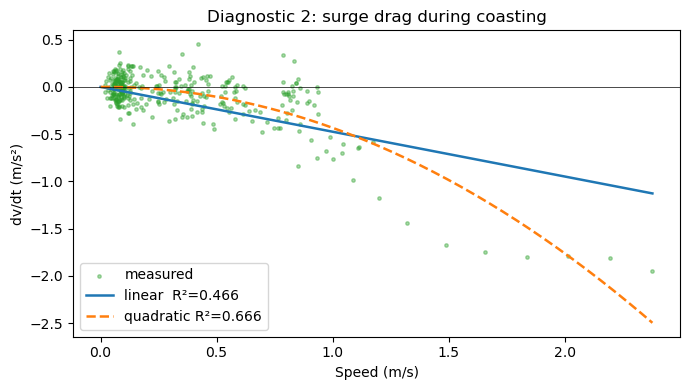

In [17]:
# Identify coasting samples: throttle near zero, not at start/end
COAST_THRESH = 0.01
coast_mask = (u < COAST_THRESH) & (t > 2.0) & (t < t[-1] - 2.0)

# Numerical derivative of speed (central differences, clipped to coasting mask)
v_dot = np.gradient(v, DT)

v_c    = v[coast_mask]
vdot_c = v_dot[coast_mask]

print(f'Coasting samples: {coast_mask.sum()}  ({coast_mask.sum()*DT:.1f} s)')

# Linear drag:    v_dot = -D1 * v
D1_lin = -np.dot(v_c, vdot_c) / np.dot(v_c, v_c)
vdot_lin = -D1_lin * v_c
r2_lin = 1 - np.sum((vdot_c - vdot_lin)**2) / np.sum((vdot_c - vdot_c.mean())**2)

# Quadratic drag: v_dot = -D1*v - D2*v^2
Phi_drag  = np.column_stack([v_c, v_c**2])
params_drag, _, _, _ = scipy.linalg.lstsq(Phi_drag, -vdot_c)
D1_q, D2_q = params_drag
vdot_quad = -(D1_q * v_c + D2_q * v_c**2)
r2_quad = 1 - np.sum((vdot_c - vdot_quad)**2) / np.sum((vdot_c - vdot_c.mean())**2)

print(f'Linear drag:    D1 = {D1_lin:.4f}  R² = {r2_lin:.4f}')
print(f'Quadratic drag: D1 = {D1_q:.4f}  D2 = {D2_q:.4f}  R² = {r2_quad:.4f}')
print(f'Improvement ΔR²: {r2_quad - r2_lin:+.4f}')

v_plot = np.linspace(0, v_c.max(), 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(v_c, vdot_c, s=6, alpha=0.4, color='C2', label='measured')
ax.plot(v_plot, -D1_lin * v_plot,                   'C0-',  lw=1.8, label=f'linear  R²={r2_lin:.3f}')
ax.plot(v_plot, -(D1_q * v_plot + D2_q * v_plot**2),'C1--', lw=1.8, label=f'quadratic R²={r2_quad:.3f}')
ax.set_xlabel('Speed (m/s)')
ax.set_ylabel('dv/dt (m/s²)')
ax.set_title('Diagnostic 2: surge drag during coasting')
ax.axhline(0, color='k', lw=0.5)
ax.legend()
plt.tight_layout()
plt.show()

### Diagnostic 3: rudder-induced surge drag

A deflected rudder generates lateral lift but also increases axial drag, slowing the vessel.
Check whether the surge model residuals (`v_measured − v_simulated`) correlate with `δ²`.
A negative correlation means large rudder angles reduce speed beyond what the throttle-only model predicts.

Correlation of δ² with surge residual: -0.0799
Rudder drag coefficient c = 0.0065 m/s per (norm²)


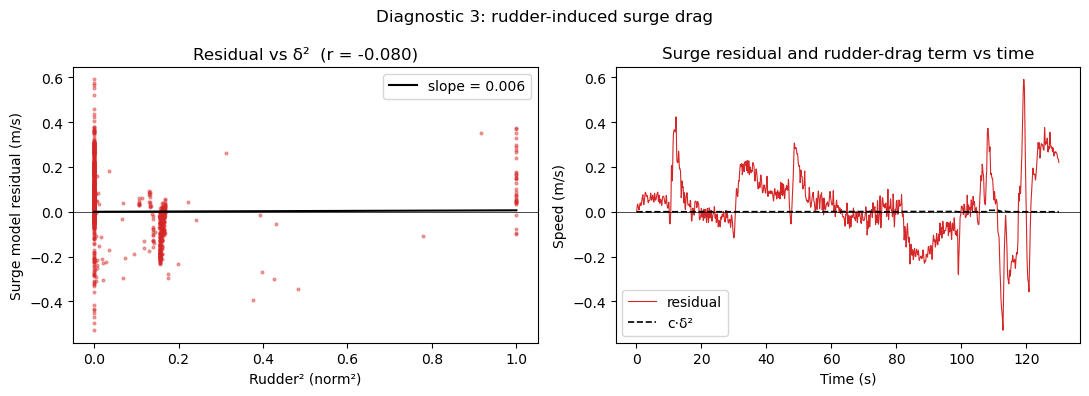

In [18]:
surge_resid = v - v_sim   # from the surge model fit above
delta_sq    = delta**2

corr = np.corrcoef(delta_sq, surge_resid)[0, 1]
print(f'Correlation of δ² with surge residual: {corr:.4f}')

# Fit a rudder-drag correction: resid ≈ c * delta²
c_rudder = np.dot(delta_sq, surge_resid) / np.dot(delta_sq, delta_sq)
print(f'Rudder drag coefficient c = {c_rudder:.4f} m/s per (norm²)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(delta_sq, surge_resid, s=4, alpha=0.4, color='C3')
x_fit = np.linspace(0, delta_sq.max(), 100)
axes[0].plot(x_fit, c_rudder * x_fit, 'k-', lw=1.5, label=f'slope = {c_rudder:.3f}')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('Rudder² (norm²)')
axes[0].set_ylabel('Surge model residual (m/s)')
axes[0].set_title(f'Residual vs δ²  (r = {corr:.3f})')
axes[0].legend()

axes[1].plot(t, surge_resid, color='C3', lw=0.8, label='residual')
axes[1].plot(t, delta_sq * c_rudder, color='k', lw=1.2, ls='--', label='c·δ²')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Speed (m/s)')
axes[1].set_title('Surge residual and rudder-drag term vs time')
axes[1].legend()

plt.suptitle('Diagnostic 3: rudder-induced surge drag', fontsize=12)
plt.tight_layout()
plt.show()

### Diagnostic summary

In [19]:
print('Diagnostic summary')
print('=' * 55)
print(f'1. Speed-dependent K_r')
print(f'   Model A (constant):  R² = {r2_A:.4f}')
print(f'   Model B (K_r·v):     R² = {r2_B:.4f}  ΔR² = {r2_B-r2_A:+.4f}')
print()
print(f'2. Surge drag during coasting')
print(f'   Linear drag:         R² = {r2_lin:.4f}')
print(f'   Quadratic drag:      R² = {r2_quad:.4f}  ΔR² = {r2_quad-r2_lin:+.4f}')
print(f'   D1 = {D1_q:.4f},  D2 = {D2_q:.4f}')
print()
print(f'3. Rudder-induced surge drag')
print(f'   Correlation(δ², residual) = {corr:.4f}')
print(f'   Drag coefficient c        = {c_rudder:.4f} m/s per norm²')

Diagnostic summary
1. Speed-dependent K_r
   Model A (constant):  R² = 0.8261
   Model B (K_r·v):     R² = 0.7945  ΔR² = -0.0315

2. Surge drag during coasting
   Linear drag:         R² = 0.4655
   Quadratic drag:      R² = 0.6661  ΔR² = +0.2006
   D1 = -0.0149,  D2 = 0.4480

3. Rudder-induced surge drag
   Correlation(δ², residual) = -0.0799
   Drag coefficient c        = 0.0065 m/s per norm²
